In [8]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor

# Load datasets
iri = pd.read_excel("../data/MON_HSS_PROFILE_SECTION.xlsx")
trf1 = pd.read_excel("../data/TRF_TREND_1.xlsx")
trf2 = pd.read_excel("../data/TRF_TREND.xlsx")

print("Raw Data Shapes:")
print("IRI:", iri.shape, "| TRF1:", trf1.shape, "| TRF2:", trf2.shape)

Raw Data Shapes:
IRI: (65534, 11) | TRF1: (65534, 7) | TRF2: (65534, 7)


In [9]:
# Convert date and extract year
iri['VISIT_DATE'] = pd.to_datetime(iri['VISIT_DATE'])
iri['YEAR'] = iri['VISIT_DATE'].dt.year

# Drop unnecessary columns
iri = iri.drop(columns=['IRI_CENTER_LANE', 'VISIT_DATE', 'VISIT_NO', 'RUN_NUMBER'])

# Average multiple runs per section per year
iri_clean = iri.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'])['MRI'].mean().reset_index()

print("Cleaned IRI Shape:", iri_clean.shape)

Cleaned IRI Shape: (11815, 5)


In [10]:
# Clean traffic files
trf1['YEAR'] = trf1['YEAR'].astype(int)
trf2['YEAR'] = trf2['YEAR'].astype(int)

# Merge both traffic files (using outer join to prevent dropping years with partial data)
trf_merged = pd.merge(
    trf1[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR', 
          'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND']],
    trf2[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR', 
          'ANNUAL_ESAL_TREND']],
    on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'],
    how='outer'
)

# Merge with IRI
df = pd.merge(
    iri_clean,
    trf_merged,
    on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'],
    how='inner'
)

# Sort and Forward-Fill missing traffic data per section to retain maximum training rows
df = df.sort_values(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'])
df['ANNUAL_ESAL_TREND'] = df.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_ESAL_TREND'].ffill()
df['AADTT_ALL_TRUCKS_TREND'] = df.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['AADTT_ALL_TRUCKS_TREND'].ffill()
df['ANNUAL_TRUCK_VOLUME_TREND'] = df.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_TRUCK_VOLUME_TREND'].ffill()

# Drop rows that still have nulls (e.g., completely missing first-year traffic data)
df = df.dropna()

print("Merged Data Shape:", df.shape)
print("Unique sections retained:", df['SHRP_ID'].nunique())

Merged Data Shape: (11739, 8)
Unique sections retained: 502


In [11]:
# Sort by section and year
df = df.sort_values(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR']).reset_index(drop=True)

# 1. Cumulative ESAL (total damage load experienced so far)
df['CUMULATIVE_ESAL'] = df.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_ESAL_TREND'].cumsum()

# 2. Target: IRI at next measurement
df['FUTURE_IRI'] = df.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['MRI'].shift(-1)

# Drop rows without a known future IRI (since they can't be used for training)
df = df.dropna(subset=['FUTURE_IRI'])

print("Training Set Shape:", df.shape)

Training Set Shape: (8935, 10)


In [12]:
# Features and target
features = ['MRI', 'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND',
            'ANNUAL_ESAL_TREND', 'CUMULATIVE_ESAL', 'YEAR']
target = 'FUTURE_IRI'

X = df[features]
y = df[target]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train XGBoost
model = XGBRegressor(n_estimators=200, learning_rate=0.05, 
                     max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Evaluate predictions
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("============================================")
print("           MODEL 1 ACCURACY REPORT          ")
print("============================================")
print(f"R² Score  : {r2:.4f}  | Range: 0 to 1")
print(f"MAE       : {mae:.4f}  | Range: 0 to ∞ (lower is better)")
print(f"RMSE      : {rmse:.4f}  | Range: 0 to ∞ (lower is better)")
print(f"MAPE      : {mape:.2f}%  | Range: 0% to 100%")
print("============================================")

           MODEL 1 ACCURACY REPORT          
R² Score  : 0.9144  | Range: 0 to 1
MAE       : 0.0901  | Range: 0 to ∞ (lower is better)
RMSE      : 0.1721  | Range: 0 to ∞ (lower is better)
MAPE      : 6.46%  | Range: 0% to 100%


In [13]:
FAILURE_THRESHOLD = 2.5

# Predict future IRI on the full dataset
df['PREDICTED_FUTURE_IRI'] = model.predict(df[features])

# Convert Predicted IRI into a 0-100 IRI Score for the RHI fusion
df['IRI_SCORE'] = (
    ((FAILURE_THRESHOLD - df['PREDICTED_FUTURE_IRI']) / FAILURE_THRESHOLD) * 100
).clip(0, 100)

print(df[['SHRP_ID', 'YEAR', 'MRI', 'PREDICTED_FUTURE_IRI', 'IRI_SCORE']].head(10))
print("\nIRI Score Distribution Stats:\n", df['IRI_SCORE'].describe())

   SHRP_ID  YEAR      MRI  PREDICTED_FUTURE_IRI  IRI_SCORE
0     0101  1995  0.65720              0.672594  73.096260
1     0101  1996  0.68120              0.703791  71.848366
2     0101  1997  0.69480              0.713883  71.444664
3     0101  1998  0.73825              0.750805  69.967781
4     0101  1999  0.71360              0.733805  70.647797
5     0101  2001  0.74300              0.756041  69.758369
6     0101  2002  0.70580              0.707809  71.687653
7     0101  2003  0.73160              0.755067  69.797325
8     0101  2004  0.77560              0.837618  66.495300
10    0101  1997  0.83630              0.850172  65.993118

IRI Score Distribution Stats:
 count    8935.000000
mean       47.406013
std        19.640507
min         0.000000
25%        35.799026
50%        50.420212
75%        62.432789
max        84.393921
Name: IRI_SCORE, dtype: float64


Model saved successfully!


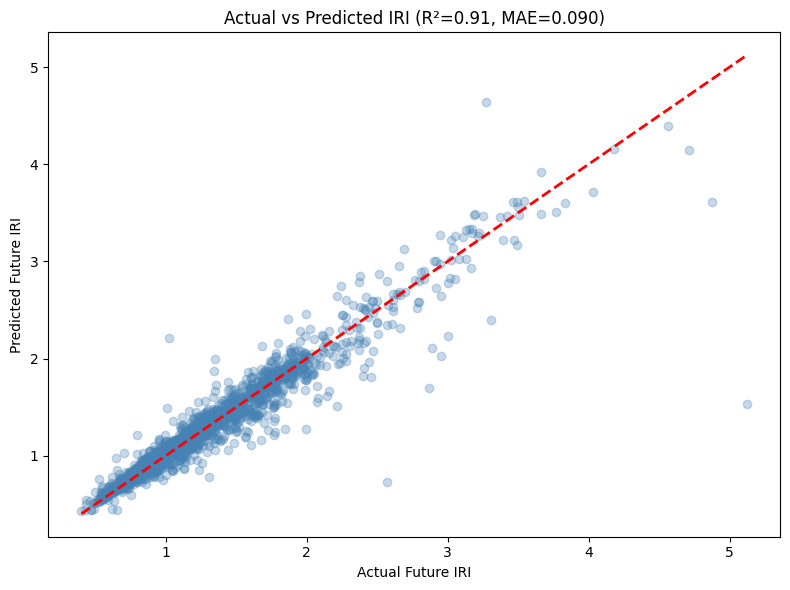

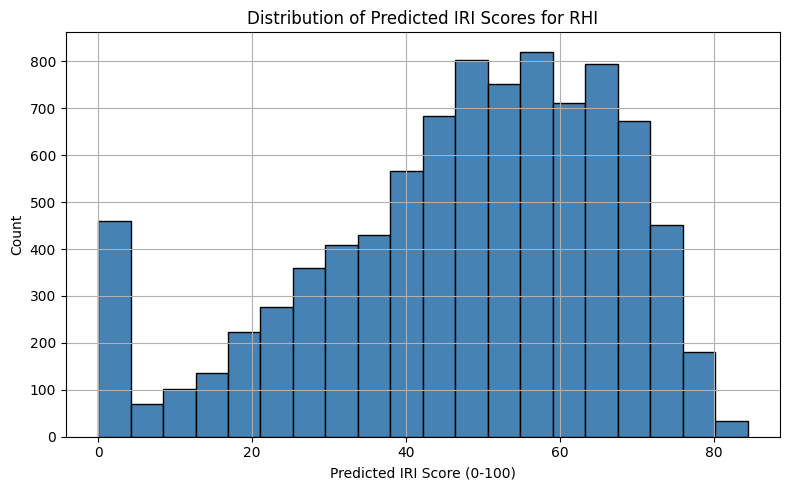

In [14]:
# Save the model
joblib.dump(model, '../models/iri_prediction_model.pkl')
print("Model saved successfully!")

# Actual vs Predicted IRI plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Future IRI")
plt.ylabel("Predicted Future IRI")
plt.title(f"Actual vs Predicted IRI (R²={r2:.2f}, MAE={mae:.3f})")
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png', dpi=150)
plt.show()

# Distribution of the derived IRI_SCORE
plt.figure(figsize=(8,5))
df['IRI_SCORE'].hist(bins=20, color='steelblue', edgecolor='black')
plt.xlabel("Predicted IRI Score (0-100)")
plt.ylabel("Count")
plt.title("Distribution of Predicted IRI Scores for RHI")
plt.tight_layout()
plt.savefig('../outputs/iri_score_distribution.png', dpi=150)
plt.show()